In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv('../data/row/archive/Data_Entry_2017.csv')
print(df.head())
print(df.shape)
print(df['Finding Labels'].value_counts().head(20))

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN 

In [28]:
# get all unique conditions
all_labels = []
for labels in df['Finding Labels']:
    all_labels.extend(labels.split('|'))

unique_labels = sorted(set(all_labels))
print(unique_labels)
print(f"Total conditions: {len(unique_labels)}")

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Total conditions: 15


In [29]:
df['num_conditions'] = df['Finding Labels'].apply(lambda x: len(x.split('|')))
print(df.head())

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  num_conditions  
0                        0.143  0.1

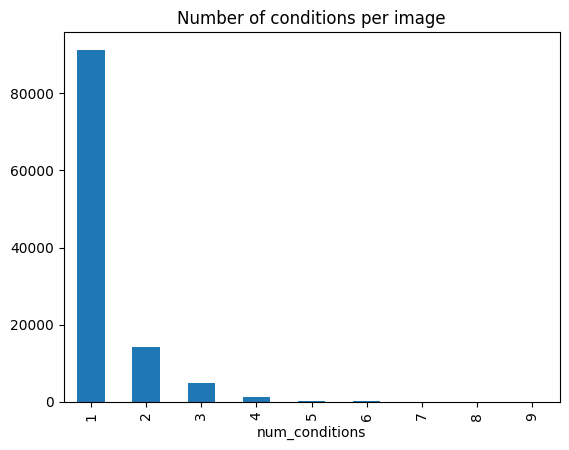

In [30]:
df['num_conditions'].value_counts().sort_index().plot(kind='bar', title='Number of conditions per image')
plt.show()

Patient Gender
M    63340
F    48780
Name: count, dtype: int64
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


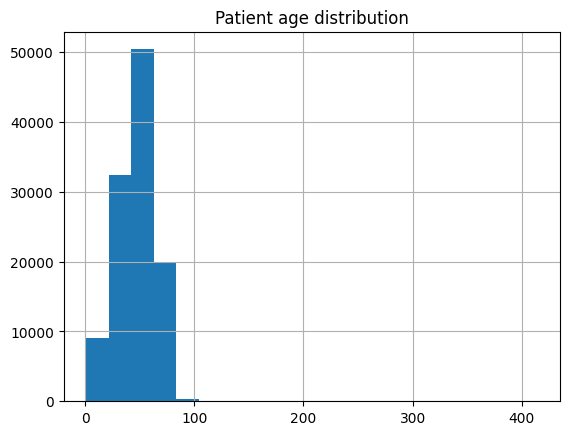

In [31]:
print(df['Patient Gender'].value_counts())
print(df['Patient Age'].describe())
df['Patient Age'].hist(bins=20)
plt.title('Patient age distribution')
plt.show()

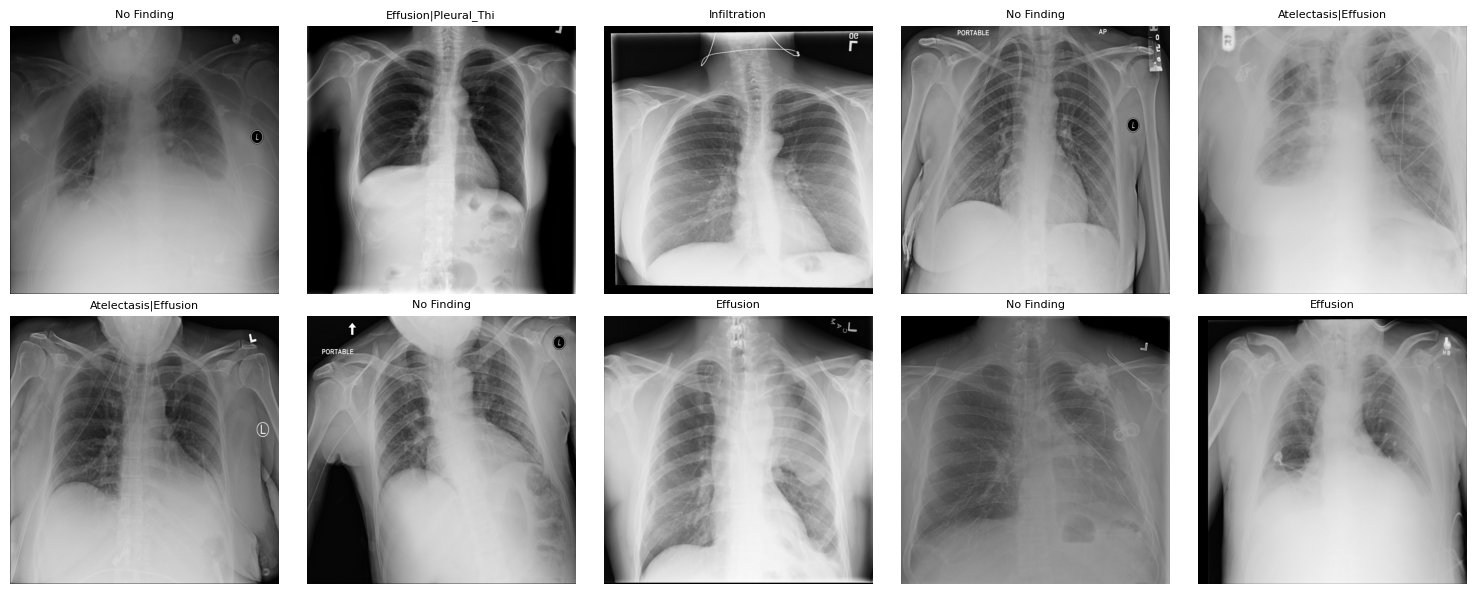

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

image_dir = r'C:\Users\deadx\OneDrive\Desktop\ChestX-ray14\data\row\archive'

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (_, row) in enumerate(df.sample(10).iterrows()):
    for folder in [f'images_{str(j).zfill(3)}' for j in range(1, 13)]:
        path = os.path.join(image_dir, folder, 'images', row['Image Index'])
        if os.path.exists(path):
            axes[i].imshow(mpimg.imread(path), cmap='gray')
            axes[i].set_title(row['Finding Labels'][:20], fontsize=8)
            axes[i].axis('off')
            break

plt.tight_layout()
plt.show()

Clean the age column 

In [33]:
df = df[df['Patient Age'] < 120]


Drop the useless columns

In [34]:
df = df.drop(columns=['Unnamed: 11', 'OriginalImage[Width', 'Height]', 
                       'OriginalImagePixelSpacing[x', 'y]'])

In [35]:
df['Patient Gender'] = df['Patient Gender'].map({'M': 0, 'F': 1})

In [36]:
df['Patient Age'] = df['Patient Age'] / 100.0

In [37]:
with open('../data/row/archive/train_val_list.txt') as f:
    train_list = [x.strip() for x in f.readlines()]

with open('../data/row/archive/test_list.txt') as f:
    test_list = [x.strip() for x in f.readlines()]

train_df = df[df['Image Index'].isin(train_list)]
test_df = df[df['Image Index'].isin(test_list)]

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

Train: 86512 | Test: 25592


In [38]:
# save cleaned CSVs
train_df.to_csv('../data/row/archive/train.csv', index=False)
test_df.to_csv('../data/row/archive/test.csv', index=False)

print("Saved train.csv and test.csv to data/")

Saved train.csv and test.csv to data/


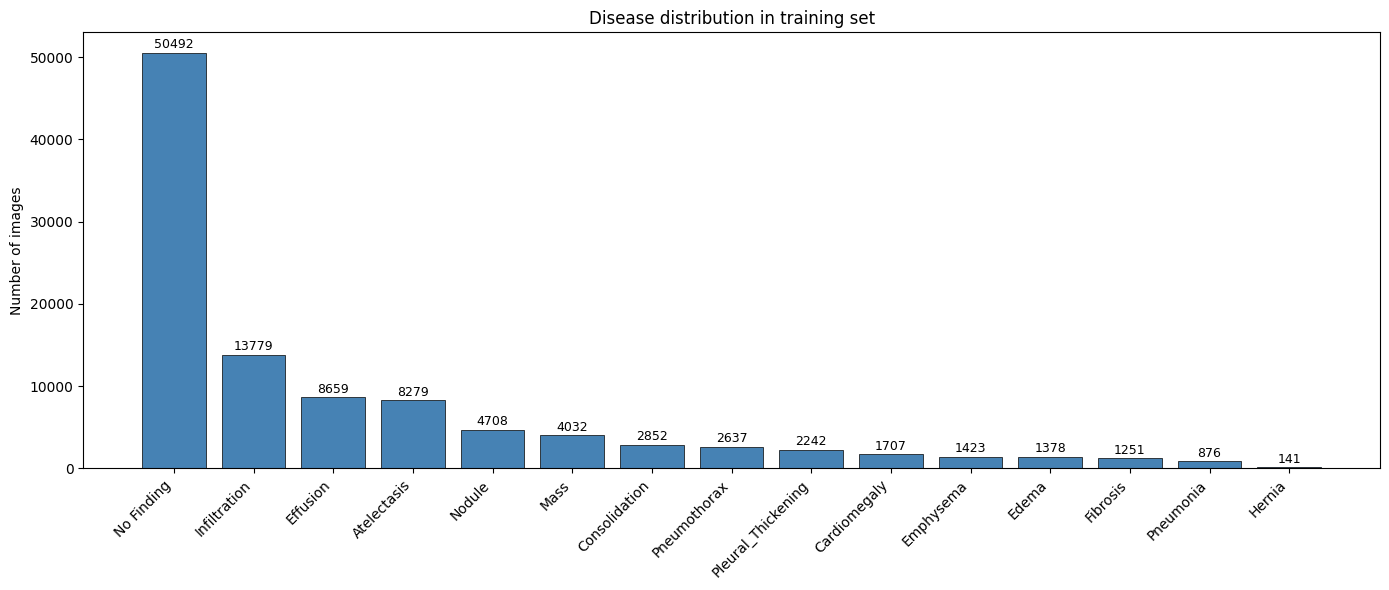

In [2]:
import matplotlib.pyplot as plt

# count positive cases per disease
disease_counts = {}
for label in LABELS:
    count = train_df['Finding Labels'].str.contains(label).sum()
    disease_counts[label] = count

# sort by count
disease_counts = dict(sorted(disease_counts.items(), key=lambda x: x[1], reverse=True))

# plot
plt.figure(figsize=(14, 6))
bars = plt.bar(disease_counts.keys(), disease_counts.values(), color='steelblue', edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of images')
plt.title('Disease distribution in training set')

# add count labels on top of each bar
for bar, count in zip(bars, disease_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import torch

train_df = pd.read_csv(r'C:\Users\deadx\OneDrive\Desktop\ChestX-ray14\data\row\train.csv')

LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration',
    'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

pos_weights = []
for label in LABELS:
    pos = train_df['Finding Labels'].str.contains(label).sum()
    neg = len(train_df) - pos
    weight = neg / pos
    print(f"{label}: {pos} positive, weight={weight:.2f}")
    pos_weights.append(weight)

print(f"\npos_weight tensor: {torch.tensor(pos_weights, dtype=torch.float32)}")

Atelectasis: 8279 positive, weight=9.45
Cardiomegaly: 1707 positive, weight=49.68
Consolidation: 2852 positive, weight=29.33
Edema: 1378 positive, weight=61.78
Effusion: 8659 positive, weight=8.99
Emphysema: 1423 positive, weight=59.80
Fibrosis: 1251 positive, weight=68.15
Hernia: 141 positive, weight=612.56
Infiltration: 13779 positive, weight=5.28
Mass: 4032 positive, weight=20.46
No Finding: 50492 positive, weight=0.71
Nodule: 4708 positive, weight=17.38
Pleural_Thickening: 2242 positive, weight=37.59
Pneumonia: 876 positive, weight=97.76
Pneumothorax: 2637 positive, weight=31.81

pos_weight tensor: tensor([  9.4496,  49.6807,  29.3338,  61.7808,   8.9910,  59.7955,  68.1543,
        612.5603,   5.2785,  20.4563,   0.7134,  17.3755,  37.5870,  97.7580,
         31.8070])


In [3]:
# cap all weights at 50
pos_weights_capped = [min(w, 50) for w in pos_weights]

for label, w in zip(LABELS, pos_weights_capped):
    print(f"{label}: {w:.2f}")

pos_weight_tensor = torch.tensor(pos_weights_capped, dtype=torch.float32)
print(f"\nFinal tensor: {pos_weight_tensor}")

Atelectasis: 9.45
Cardiomegaly: 49.68
Consolidation: 29.33
Edema: 50.00
Effusion: 8.99
Emphysema: 50.00
Fibrosis: 50.00
Hernia: 50.00
Infiltration: 5.28
Mass: 20.46
No Finding: 0.71
Nodule: 17.38
Pleural_Thickening: 37.59
Pneumonia: 50.00
Pneumothorax: 31.81

Final tensor: tensor([ 9.4496, 49.6807, 29.3338, 50.0000,  8.9910, 50.0000, 50.0000, 50.0000,
         5.2785, 20.4563,  0.7134, 17.3755, 37.5870, 50.0000, 31.8070])
